# Probabilistic Forecast Evaluation Under Market Pressure  
## Case Study: Super Bowl LX

This case study evaluates probabilistic forecast calibration under high-variance market conditions, separating structural signal from outcome variance.

---

### Objective

Evaluate whether independently estimated probabilities can generate positive edge relative to market-implied expectations within a high-variance forecasting environment.

This case study focuses on:

- Quantifying edge versus market baseline  
- Separating structural predictive signal from outcome variance  
- Identifying and refining model bias under extreme conditions  

### Methodology 

This analysis evaluates forecast calibration by comparing independently estimated probabilities against market-implied baselines for each prop.

The framework follows five structured steps: 

1. Market Baseline Identification
   Record the baseline market line and final pregame snapshot to establish the reference expectation.

2. Independent Probability Estimation
   Estimate outcome probability using role concentration, matchup dynamics, pressure exposure, and projected game script — independent of market bias.
   Estimated probabilities were finalized prior to kickoff using the final pregame market snapshot as reference to prevent hindsight bias.

3. Edge Calculation  
   Compute edge in percentage points:

   Edge (pp) = Estimated Probability − Market Implied Probability

4. Outcome Evaluation  
   After the event, classify each forecast as HIT or MISS and encode results as binary (1/0) for calibration analysis.

5. Structural Classification  
   Categorize each outcome as:
   - Structural Win / Structural Loss (logic-driven signal)
   - Variance Win / Variance Loss (outcome deviated despite sound logic)

Calibration metrics (hit rate, edge distribution, and correlation between edge magnitude and outcome) are then used to assess directional model validity.

## Assumptions

- Market implied probabilities represent efficient baseline expectations.
- Estimated probabilities are formed independently from market bias.
- Outcomes are encoded as binary (HIT/MISS) for calibration purposes.
- Edge magnitude (pp) is treated as comparable across prop types.
- Classification of structural vs variance outcomes involves informed qualitative judgment.

## Market Timing Context

- Baseline Capture Date: 2026-02-03  
- Final Market Snapshot: 2026-02-06 18:50  
- Kickoff: 2026-02-08 17:30  
- Δ to Kickoff: 46.7 hours  

All edge calculations reflect the final pregame market snapshot.

In [205]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from datetime import datetime 

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## Data Dictionary 

### Table 1 : Executive Results ('df_summary')

Column | Type | Description 
|---|---|---|
| Player | string | Player name |
| Prop | string | Prop market label (e.g., "Rush Yds O36.5") |
| Tier | string | Confidence tier (Core / Median / Boom / Divergence) |
| Lean | string | Forecast direction (Over/Under/Yes/No) |
| Edge_pp | int/float | Edge in percentage points: Estimated %  - Market Implied % |
| Final | numeric | Final observed stat/outcome value | 
| Result | string | HIT or MISS |
| Outcome_Type | string | Structural Win/Loss or Variance Win/Loss |
| Hit | int | Binary outcome indicator (1 = HIT, 0 = MISS) |
| Edge_Bucket | category | Binned edge ranges used for calibration diagnostics | 

In [206]:
summary_data = [
    ["Drake Maye", "Rush Yds O36.5", "Core", "Over", 11, 37, "HIT", "Structural Win"],
    ["Kenneth Walker III", "Rec Yds O20.5", "Core", "Over", 9, 26, "HIT", "Structural Win"],
    ["Drake Maye", "Throws INT", "Divergence", "Yes", 12, 2, "HIT", "Structural Win"],
    ["TreVeyon Henderson", "1+ Reception", "Median", "Yes", 13, 1, "HIT", "Structural Win"],
    ["Sam Darnold", "1.5 Pass TD", "Boom", "Over", 6, 1, "MISS", "Structural Loss"],
    ["Kayshon Boutte", "Rec Yds O30.5", "Median", "Over", 5, 21, "MISS", "Structural Loss"],
    ["Jaxon Smith-Njigba", "Receptions O6.5", "Median", "Over", 7, 4, "MISS", "Structural Loss"],
    ["Jaxon Smith-Njigba", "Anytime TD", "Boom", "Yes", 5, 0, "MISS", "Structural Loss"],
    ["Rashid Shaheed", "Longest Rec O14.5", "Boom", "Over", 3, 16, "HIT", "Variance Win"],
    ["Mack Hollins", "Rec Yds O26.5", "Median", "Over", 2, 78, "HIT", "Variance Win"],
]

df_summary = pd.DataFrame(summary_data, columns = [ 
    "Player", "Prop", "Tier", "Lean", "Edge_pp", "Final", "Result", "Outcome_Type"
])

df_summary

,Player,Prop,Tier,Lean,Edge_pp,Final,Result,Outcome_Type
0,Drake Maye,Rush Yds O36.5,Core,Over,11,37,HIT,Structural Win
1,Kenneth Walker III,Rec Yds O20.5,Core,Over,9,26,HIT,Structural Win
2,Drake Maye,Throws INT,Divergence,Yes,12,2,HIT,Structural Win
3,TreVeyon Henderson,1+ Reception,Median,Yes,13,1,HIT,Structural Win
4,Sam Darnold,1.5 Pass TD,Boom,Over,6,1,MISS,Structural Loss
5,Kayshon Boutte,Rec Yds O30.5,Median,Over,5,21,MISS,Structural Loss
6,Jaxon Smith-Njigba,Receptions O6.5,Median,Over,7,4,MISS,Structural Loss
7,Jaxon Smith-Njigba,Anytime TD,Boom,Yes,5,0,MISS,Structural Loss
8,Rashid Shaheed,Longest Rec O14.5,Boom,Over,3,16,HIT,Variance Win
9,Mack Hollins,Rec Yds O26.5,Median,Over,2,78,HIT,Variance Win


### Table 2 : Market Detail ('df_market')

| Column | Type | Description |
|---|---|---|
| Player | string | Player/market label aligned to Table 1 |
| Baseline | string/float | First recorded market line |
| Current | string/float | Final pregame market snapshot line | 
| Market_Move | string | Up/Down/Flat | 
| Market_Implied_% | int/float | Market baseline probability estimate | 
| My_Estimated_% | int/float | Independently estimated probability |

In [207]:
market_data = [
    ["Drake Maye (Rush)", 36.5, 37.5, "Up", 52, 63],
    ["Kenneth Walker", 20.5, 20.5, "Flat", 52, 61],
    ["Drake Maye (INT)", "+1", "0.5 Yes/No", "Flat", 48, 60],
    ["Henderson", 0.5, 0.5, "Flat", 55, 68],
    ["Darnold", 1.5, 1.5, "Flat", 52, 58],
    ["Boutte", 30.5, 29.5, "Down", 52, 57],
    ["JSN (Rec)", 6.5, 6.5, "Flat", 52, 59],
    ["JSN (TD)", "Yes", "Yes", "Flat", 45, 50],
    ["Shaheed", 14.5, 14.5, "Flat", 50, 53],
    ["Hollins", 26.5, 26.5, "Flat", 52, 54],
]

df_market = pd.DataFrame(market_data, columns=[
    "Player", "Baseline", "Current", "Market_Move", "Market_Implied_%", "Model_Estimated_%"
])

df_market

,Player,Baseline,Current,Market_Move,Market_Implied_%,Model_Estimated_%
0,Drake Maye (Rush),36.5,37.5,Up,52,63
1,Kenneth Walker,20.5,20.5,Flat,52,61
2,Drake Maye (INT),+1,0.5 Yes/No,Flat,48,60
3,Henderson,0.5,0.5,Flat,55,68
4,Darnold,1.5,1.5,Flat,52,58
5,Boutte,30.5,29.5,Down,52,57
6,JSN (Rec),6.5,6.5,Flat,52,59
7,JSN (TD),Yes,Yes,Flat,45,50
8,Shaheed,14.5,14.5,Flat,50,53
9,Hollins,26.5,26.5,Flat,52,54


In [208]:
df_summary["Hit"] = df_summary["Result"].apply(lambda x: 1 if x == "HIT" else 0)

overall_hit_rate = df_summary["Hit"].mean()
hit_by_tier = df_summary.groupby("Tier")["Hit"].mean()
avg_edge_hit = df_summary[df_summary["Hit"] == 1]["Edge_pp"].mean()
avg_edge_miss = df_summary[df_summary["Hit"] == 0]["Edge_pp"].mean()

overall_hit_rate, hit_by_tier, avg_edge_hit, avg_edge_miss


(np.float64(0.6),
 Tier
 Boom          0.333333
 Core          1.000000
 Divergence    1.000000
 Median        0.500000
 Name: Hit, dtype: float64,
 np.float64(8.333333333333334),
 np.float64(5.75))

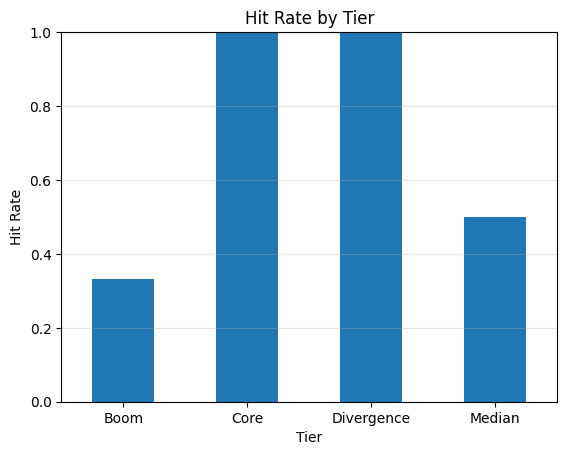

In [209]:
hit_rate_by_tier = df_summary.groupby("Tier")["Hit"].mean()

hit_rate_by_tier.plot(kind="bar")
ax = hit_rate_by_tier.plot(kind = "bar")
plt.title("Hit Rate by Tier")
plt.ylabel("Hit Rate")
plt.ylim(0, 1)
plt.grid(True, axis = "y", alpha = 0.3)
plt.xticks(rotation = 0)
plt.show()


## Calibration Analysis

This section evaluates whether estimated edge (percentage points vs market baseline) correlates with outcomes,
and whether results are driven by structural signal or variance.

Key questions:
1. Do higher edge estimates produce higher hit rates?
2. Are wins primarily structural or variance-driven?
3. Which tiers appear well-calibrated vs noisy?
4. Where does the framework show systematic bias?


In [210]:
# Compare average edge for HIT vs MISS
calibration_summary = df_summary.groupby("Result")["Edge_pp"].agg(["count", "mean", "median"]).sort_index()

calibration_summary

,count,mean,median
Result,,,
HIT,6,8.333333,10.0
MISS,4,5.750000,5.5


In [211]:
# Bucket edges to check if higher edges convert more often
bins = [-1, 3, 6, 9, 12, 20]
labels = ["<=3", "4-6", "7-9", "10-12", "13+"]

df_summary["Edge_Bucket"] = pd.cut(df_summary["Edge_pp"], bins=bins, labels=labels)

bucket_perf = (
    df_summary
    .groupby("Edge_Bucket", observed=False)["Hit"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "hit_rate"})
)
bucket_perf

,count,hit_rate
Edge_Bucket,,
<=3,2,1.0
4-6,3,0.0
7-9,2,0.5
10-12,2,1.0
13+,1,1.0


In [212]:
# Structural vs variance performance
outcome_perf = df_summary.groupby("Outcome_Type")["Hit"].agg(["count", "mean"]).rename(columns={"mean": "hit_rate"})
outcome_perf

,count,hit_rate
Outcome_Type,,
Structural Loss,4,0.0
Structural Win,4,1.0
Variance Win,2,1.0


In [213]:
tier_calibration = df_summary.groupby("Tier").agg(
    props=("Player", "count"),
    hit_rate=("Hit", "mean"),
    avg_edge=("Edge_pp", "mean"),
    median_edge=("Edge_pp", "median")
).sort_values("hit_rate", ascending=False)

tier_calibration


,props,hit_rate,avg_edge,median_edge
Tier,,,,
Core,2,1.000000,10.000000,10.0
Divergence,1,1.000000,12.000000,12.0
Median,4,0.500000,6.750000,6.0
Boom,3,0.333333,4.666667,5.0


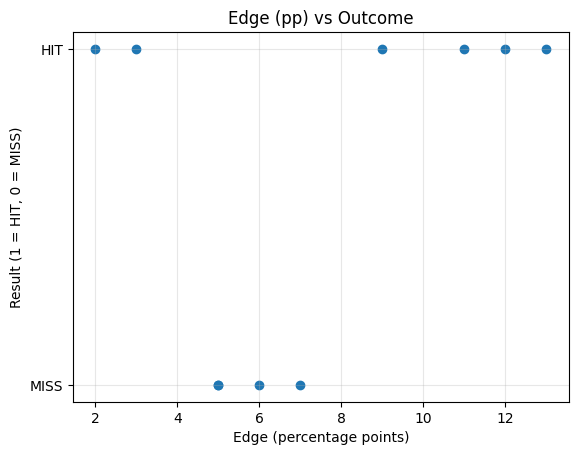

In [214]:
# Scatter: Edge vs outcome (HIT=1, MISS=0)
np.random.seed(42)

y_jitter = df_summary['Hit'] + np.random.normal(0, 0.03, size = len(df_summary))

plt.figure()
plt.scatter(df_summary["Edge_pp"], df_summary["Hit"])
plt.title("Edge (pp) vs Outcome")
plt.xlabel("Edge (percentage points)")
plt.ylabel("Result (1 = HIT, 0 = MISS)")
plt.yticks([0, 1], ["MISS", "HIT"])
plt.grid(True, alpha=0.3)
plt.show()

## Postgame Structural Summary

### Structural Wins
- Drake Maye — Rush Yds O36.5  
- Kenneth Walker III — Rec Yds O20.5  
- Drake Maye — Throws INT  
- TreVeyon Henderson — 1+ Reception  

### Structural Losses
- Sam Darnold — 1.5 Pass TD  
- Kayshon Boutte — Rec Yds O30.5  
- Jaxon Smith-Njigba — Receptions O6.5  
- Jaxon Smith-Njigba — Anytime TD  

### Variance Wins
- Rashid Shaheed — Longest Rec O14.5  
- Mack Hollins — Rec Yds O26.5  

### Variance Losses
- None in this sample.


In [215]:
# Basic derived insights
highest_edge = df_summary.loc[df_summary["Edge_pp"].idxmax()]
lowest_edge_hit = df_summary[(df_summary["Hit"] == 1)].sort_values("Edge_pp").iloc[0]
worst_edge_miss = df_summary[(df_summary["Hit"] == 0)].sort_values("Edge_pp", ascending=False).iloc[0]

print("Core Discoveries\n")

print(f"- Highest modeled edge: {highest_edge['Player']} ({highest_edge['Edge_pp']} pp).")
print(f"- Lowest-edge win (possible variance): {lowest_edge_hit['Player']} ({lowest_edge_hit['Edge_pp']} pp).")
print(f"- Highest-edge miss (calibration check): {worst_edge_miss['Player']} ({worst_edge_miss['Edge_pp']} pp).")
print(f"- Overall hit rate: {round(df_summary['Hit'].mean()*100,1)}%.")

Core Discoveries

- Highest modeled edge: TreVeyon Henderson (13 pp).
- Lowest-edge win (possible variance): Mack Hollins (2 pp).
- Highest-edge miss (calibration check): Jaxon Smith-Njigba (7 pp).
- Overall hit rate: 60.0%.


## Model Calibration Adjustments

Based on Super Bowl LX evaluation:

- Increase weighting of pressure-based quarterback volatility.
- Prioritize role-based usage floors over touchdown volatility.
- Apply coverage suppression adjustment to WR reception projections versus elite defenders.
- Require concentrated red-zone role confirmation for TD props.
- Avoid speculative low-snap binary props without route participation validation.

This case study confirms that structural edge categories (pressure, role, funnel) are more stable predictors than volatility-dependent markets.

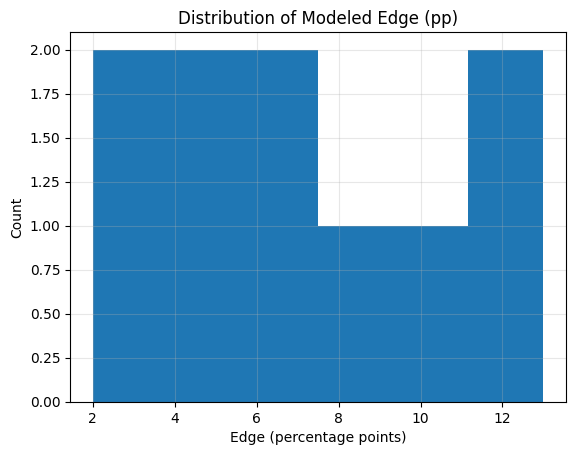

In [216]:
plt.figure()
plt.hist(df_summary["Edge_pp"], bins=6)
plt.title("Distribution of Modeled Edge (pp)")
plt.xlabel("Edge (percentage points)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

In [217]:
corr_edge_hit = df_summary["Edge_pp"].corr(df_summary["Hit"])
corr_edge_hit

corr_edge_hit_rounded = round(corr_edge_hit, 2)
corr_edge_hit_rounded 

print(f"Edge_pp vs Hit correlation: {corr_edge_hit_rounded} (directional, n=10)")

Edge_pp vs Hit correlation: 0.35 (directional, n=10)


## Interpretation: Edge Calibration

The correlation between modeled edge (pp) and outcome (HIT=1, MISS=0) is r ≈ **0.35**.

- A **positive** correlation suggests larger modeled edges tend to convert to wins more often.
- A value **near 0** suggests weak calibration (edge size does not strongly separate wins and losses).
- A **negative** correlation suggests miscalibration (higher edges are not translating into better outcomes).

Given this is a single high-variance case study with **n=10**, correlation is directionally informative rather than statistically definitive.

## Key Findings

- Larger modeled edges demonstrated directional calibration (r ≈ 0.35).
- Pressure-driven QB volatility produced the strongest structural signal.
- Scoring markets showed lower stability than usage/pressure props in this sample
- Structural classification clarified where logic failed versus randomness.

## Conclusion

This case study evaluated a probabilistic forecasting framework under high-variance, high-stakes conditions (Super Bowl LX) by comparing independently estimated probabilities against market-implied baselines.

Across 10 player-level forecasts, the framework produced a 60% hit rate and successfully differentiated structural signal from variance-driven outcomes. Calibration diagnostics indicated a moderate positive relationship between modeled edge and realized results (Edge_pp vs Hit correlation, r ≈ 0.35), suggesting that larger estimated advantages tended to convert more frequently within this sample.

Structural strength was most evident in pressure-correlated quarterback volatility and role-based usage concentration, while volatility-heavy scoring markets and coverage-suppressed receiver outcomes generated the majority of structural misses.

Although limited by sample size, results support the framework as directionally calibrated under stress conditions, with clearly identified refinement points to improve stability and reduce exposure to variance in future iterations.


## Limitations 

- Sample size is small (n=10), limiting statistical power
- Results reflect a single high-variance event (Super Bowl LX)
- Market implied probabilities are approximated rather than derived from exact sportsbook pricing models
- Correlation (0.35) indicates directional alignment but is not statistically significant at this sample size
- Structural vs variance classification involves qualitative judgment

This analysis should be interpreted as a calibration case study rather than a definitive predictive model.

## Future Work

- Expand the evaluation across multiple games and seasons to increase sample size and improve calibration stability.
- Formalize pressure, coverage, and role concentration inputs (e.g., pressure rate, route participation, primary coverage assignments) directly into probability estimation.
- Derive market implied probabilities from sportsbook odds using standardized conversion formulas rather than approximations.
- Evaluate edge performance across larger datasets to assess long-term directional consistency.

In [218]:
run_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Notebook run timestamp: {run_timestamp}")
print("Project: Probabilistic Forecast Evaluation Under Market Pressure — Super Bowl LX Case Study")

Notebook run timestamp: 2026-02-19 15:49:04
Project: Probabilistic Forecast Evaluation Under Market Pressure — Super Bowl LX Case Study


In [219]:
# Export tables for reproducibility 

df_summary.to_csv("super_bowl_lx_results_summary.csv", index = False)
df_market.to_csv("super_bowl_lx_market_detail.csv", index = False)

print("Exported:")
print("- super_bowl_lx_results_summary.csv")
print("- super_bowl_lx_market_detail.csv")

Exported:
- super_bowl_lx_results_summary.csv
- super_bowl_lx_market_detail.csv
